# Celebal Summer Internship 2026 — Week 2
## E-Commerce Sales Database Analysis
**Author:** Kashish &nbsp;|&nbsp; **Tools:** Python, SQLite, Pandas, Matplotlib &nbsp;|&nbsp; **Dataset:** Superstore (9,994 rows) + ShopEase Tables


## Setup

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

con = sqlite3.connect('shopease.db')

superstore = pd.read_csv('superstore.csv', encoding='latin-1')
superstore.columns = [c.strip().lower().replace(' ', '_') for c in superstore.columns]
superstore['order_date'] = pd.to_datetime(superstore['order_date'], format='%m/%d/%Y')
superstore['year_month'] = superstore['order_date'].dt.to_period('M').astype(str)
superstore.to_sql('sales', con, if_exists='replace', index=False)

for tbl in ['order_items', 'orders', 'products', 'customers']:
    con.execute(f'DROP TABLE IF EXISTS {tbl}')

con.executescript(open('schema.sql').read())
con.executescript(open('data.sql').read())
con.commit()

print("Database ready.")
print("Tables:", pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", con)['name'].tolist())


FileNotFoundError: [Errno 2] No such file or directory: 'superstore.csv'

---
## Section A — SQL Basics

### Q1 · All rows from customers

In [ ]:
pd.read_sql("SELECT * FROM customers", con)

,customer_id,first_name,last_name,email,city,state,join_date,is_premium
0,101,Aarav,Sharma,aarav.s@email.com,Mumbai,Maharashtra,2024-01-15,1
1,102,Priya,Patel,priya.p@email.com,Ahmedabad,Gujarat,2024-02-20,0
2,103,Rohan,Gupta,rohan.g@email.com,Delhi,Delhi,2024-03-10,1
3,104,Sneha,Reddy,sneha.r@email.com,Hyderabad,Telangana,2024-04-05,0
4,105,Vikram,Singh,vikram.s@email.com,Jaipur,Rajasthan,2024-05-12,1
5,106,Ananya,Iyer,ananya.i@email.com,Chennai,Tamil Nadu,2024-06-18,0
6,107,Karan,Mehta,karan.m@email.com,Pune,Maharashtra,2024-07-22,1
7,108,Divya,Nair,divya.n@email.com,Kochi,Kerala,2024-08-30,0


### Q2 · first_name, last_name, city only

In [ ]:
pd.read_sql("SELECT first_name, last_name, city FROM customers", con)

,first_name,last_name,city
0,Aarav,Sharma,Mumbai
1,Priya,Patel,Ahmedabad
2,Rohan,Gupta,Delhi
3,Sneha,Reddy,Hyderabad
4,Vikram,Singh,Jaipur
5,Ananya,Iyer,Chennai
6,Karan,Mehta,Pune
7,Divya,Nair,Kochi


### Q3 · Unique product categories

In [ ]:
pd.read_sql("SELECT DISTINCT category FROM products ORDER BY category", con)

,category
0,Clothing
1,Electronics
2,Home


### Q4 · Primary Keys
| Table | Primary Key |
|---|---|
| customers | customer_id |
| products | product_id |
| orders | order_id |
| order_items | item_id |

A primary key must be **UNIQUE** so every row is individually identifiable — duplicate PKs would make JOINs return ambiguous results. It must be **NOT NULL** because a null identity cannot be referenced by foreign keys or used to locate a specific row.


In [ ]:
pd.read_sql("""
SELECT 'customers'  AS table_name, COUNT(*) AS total_rows, COUNT(customer_id) AS non_null_pk FROM customers
UNION ALL
SELECT 'products',                  COUNT(*),               COUNT(product_id)  FROM products
UNION ALL
SELECT 'orders',                    COUNT(*),               COUNT(order_id)    FROM orders
UNION ALL
SELECT 'order_items',               COUNT(*),               COUNT(item_id)     FROM order_items
""", con)

,table_name,total_rows,non_null_pk
0,customers,8,8
1,products,8,8
2,orders,10,10
3,order_items,15,15


### Q5 · Constraints on the email column
The `email` column has `UNIQUE NOT NULL` — every email must exist and be one-of-a-kind. Inserting a duplicate email throws:  
`UNIQUE constraint failed: customers.email`


In [ ]:
try:
    con.execute("""INSERT INTO customers VALUES
        (109, 'Test', 'User', 'aarav.s@email.com', 'Mumbai', 'Maharashtra', '2024-09-01', 0)""")
except Exception as e:
    print(f"Error: {e}")

Error: UNIQUE constraint failed: customers.email


### Q6 · INSERT with unit_price = -50
The `CHECK (unit_price > 0)` constraint blocks negative prices at the database level.


In [ ]:
try:
    con.execute("INSERT INTO products VALUES (209, 'Bad Item', 'Electronics', 'FakeBrand', -50.00, 10)")
except Exception as e:
    print(f"Error: {e}")

Error: CHECK constraint failed: unit_price > 0


---
## Section B — Filtering & Optimization

### Q7 · Orders with status = Delivered

In [ ]:
pd.read_sql("SELECT * FROM orders WHERE status = 'Delivered' ORDER BY order_date", con)

,order_id,customer_id,order_date,status,total_amount
0,1001,101,2024-08-01,Delivered,4498
1,1002,102,2024-08-03,Delivered,799
2,1004,101,2024-08-10,Delivered,3499
3,1006,105,2024-08-15,Delivered,5898
4,1008,103,2024-08-20,Delivered,899
5,1010,108,2024-08-28,Delivered,1598


### Q8 · Electronics with unit_price > 2000

In [ ]:
pd.read_sql("""
SELECT product_id, product_name, brand, unit_price
FROM   products
WHERE  category = 'Electronics' AND unit_price > 2000
ORDER BY unit_price DESC
""", con)

,product_id,product_name,brand,unit_price
0,205,Bluetooth Speaker,JBL,3499
1,203,Smart Watch,Noise,2999


### Q9 · Maharashtra customers who joined in 2024

In [ ]:
pd.read_sql("""
SELECT customer_id, first_name, last_name, city, state, join_date
FROM   customers
WHERE  state = 'Maharashtra'
  AND  join_date >= '2024-01-01'
  AND  join_date <  '2025-01-01'
""", con)

,customer_id,first_name,last_name,city,state,join_date
0,101,Aarav,Sharma,Mumbai,Maharashtra,2024-01-15
1,107,Karan,Mehta,Pune,Maharashtra,2024-07-22


### Q10 · Orders Aug 10–25 excluding Cancelled

In [ ]:
pd.read_sql("""
SELECT order_id, customer_id, order_date, status, total_amount
FROM   orders
WHERE  order_date BETWEEN '2024-08-10' AND '2024-08-25'
  AND  status <> 'Cancelled'
ORDER BY order_date
""", con)

,order_id,customer_id,order_date,status,total_amount
0,1004,101,2024-08-10,Delivered,3499
1,1006,105,2024-08-15,Delivered,5898
2,1007,106,2024-08-18,Pending,1299
3,1008,103,2024-08-20,Delivered,899
4,1009,107,2024-08-25,Shipped,6098


### Q11 · What does idx_orders_date do?
`idx_orders_date` is a B-Tree index on `orders(order_date)`. Without it the DB reads every row to find matching dates (full table scan, O(n)). With the index it jumps directly to the matching range using binary search (O(log n)). On a million-row table this takes the query from seconds down to milliseconds.

The query below benefits directly from this index:


In [ ]:
pd.read_sql("""
SELECT order_id, order_date, status, total_amount
FROM   orders
WHERE  order_date BETWEEN '2024-08-10' AND '2024-08-25'
""", con)

,order_id,order_date,status,total_amount
0,1004,2024-08-10,Delivered,3499
1,1005,2024-08-12,Cancelled,2999
2,1006,2024-08-15,Delivered,5898
3,1007,2024-08-18,Pending,1299
4,1008,2024-08-20,Delivered,899
5,1009,2024-08-25,Shipped,6098


### Q12 · Is YEAR(join_date) = 2024 index-friendly?
**No.** Wrapping a column inside a function stops the DB from using the index — it has to compute `YEAR()` on every single row first. This is called a non-SARGable query.

**Rewrite (SARGable):**


In [ ]:
result = pd.read_sql("""
SELECT customer_id, first_name, join_date
FROM   customers
WHERE  join_date >= '2024-01-01'
  AND  join_date <  '2025-01-01'
""", con)
result

,customer_id,first_name,join_date
0,101,Aarav,2024-01-15
1,102,Priya,2024-02-20
2,103,Rohan,2024-03-10
3,104,Sneha,2024-04-05
4,105,Vikram,2024-05-12
5,106,Ananya,2024-06-18
6,107,Karan,2024-07-22
7,108,Divya,2024-08-30


---
## Section C — Aggregation

### Q13 · Total number of orders

In [ ]:
pd.read_sql("SELECT COUNT(*) AS total_orders FROM orders", con)

,total_orders
0,10


### Q14 · Total revenue from Delivered orders

In [ ]:
pd.read_sql("""
SELECT SUM(total_amount) AS total_revenue,
       COUNT(*)          AS order_count,
       ROUND(AVG(total_amount), 2) AS avg_order_value
FROM   orders
WHERE  status = 'Delivered'
""", con)

,total_revenue,order_count,avg_order_value
0,17191,6,2865.17


### Q15 · Average unit price per category

,category,avg_price,products
0,Clothing,2699.00,2
1,Electronics,2224.00,4
2,Home,949.00,2


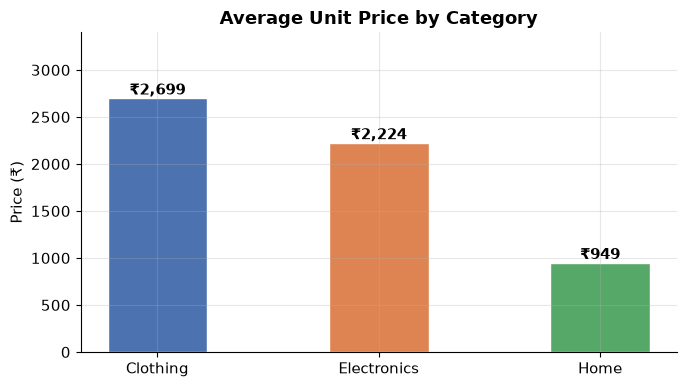

In [ ]:
q15 = pd.read_sql("""
SELECT   category,
         ROUND(AVG(unit_price), 2) AS avg_price,
         COUNT(*)                  AS products
FROM     products
GROUP BY category
ORDER BY avg_price DESC
""", con)

display(q15)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(q15['category'], q15['avg_price'],
              color=['#4C72B0', '#DD8452', '#55A868'], width=0.45, edgecolor='white')
for b, v in zip(bars, q15['avg_price']):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 40,
            f'₹{v:,.0f}', ha='center', fontweight='bold')
ax.set_title('Average Unit Price by Category', fontweight='bold')
ax.set_ylabel('Price (₹)')
ax.set_ylim(0, 3400)
plt.tight_layout()
plt.show()

### Q16 · Order count and revenue per status

,status,order_count,total_revenue,avg_value
0,Delivered,6,17191,2865.17
1,Shipped,2,13596,6798.00
2,Cancelled,1,2999,2999.00
3,Pending,1,1299,1299.00


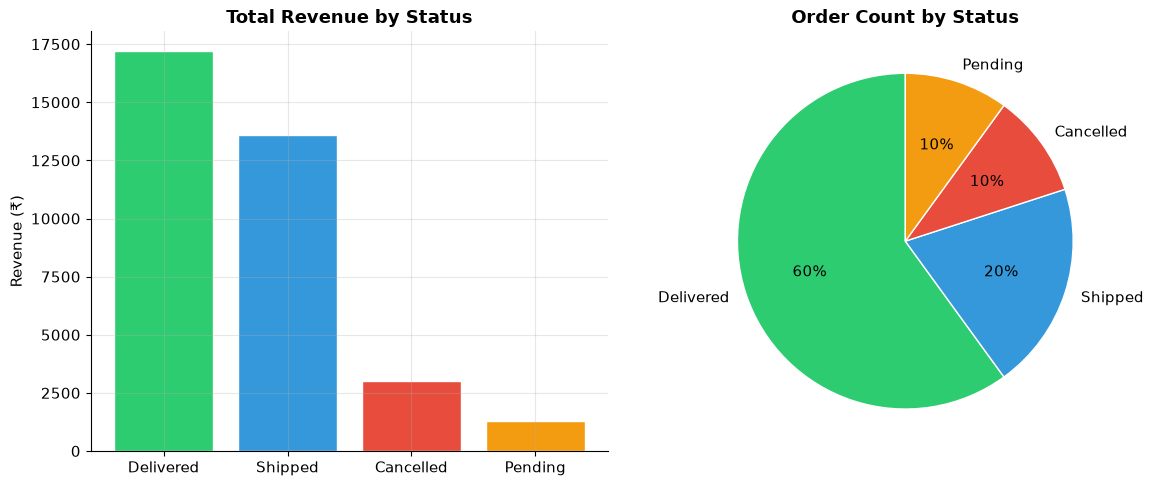

In [ ]:
q16 = pd.read_sql("""
SELECT   status,
         COUNT(*)                    AS order_count,
         SUM(total_amount)           AS total_revenue,
         ROUND(AVG(total_amount), 2) AS avg_value
FROM     orders
GROUP BY status
ORDER BY total_revenue DESC
""", con)

display(q16)

colors = {'Delivered': '#2ecc71', 'Shipped': '#3498db', 'Cancelled': '#e74c3c', 'Pending': '#f39c12'}
c = [colors[s] for s in q16['status']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.bar(q16['status'], q16['total_revenue'], color=c, edgecolor='white')
ax1.set_title('Total Revenue by Status', fontweight='bold')
ax1.set_ylabel('Revenue (₹)')

ax2.pie(q16['order_count'], labels=q16['status'], autopct='%1.0f%%',
        colors=c, startangle=90, wedgeprops={'edgecolor': 'white'})
ax2.set_title('Order Count by Status', fontweight='bold')
plt.tight_layout()
plt.show()

### Q17 · Most expensive and cheapest product per category

In [ ]:
pd.read_sql("""
SELECT   category,
         MAX(unit_price) AS max_price,
         MIN(unit_price) AS min_price,
         MAX(unit_price) - MIN(unit_price) AS price_range
FROM     products
GROUP BY category
ORDER BY category
""", con)

,category,max_price,min_price,price_range
0,Clothing,4599,799,3800
1,Electronics,3499,899,2600
2,Home,1299,599,700


### Q18 · Categories where avg price > ₹2000 (HAVING)

In [ ]:
result = pd.read_sql("""
SELECT   category,
         ROUND(AVG(unit_price), 2) AS avg_price
FROM     products
GROUP BY category
HAVING   AVG(unit_price) > 2000
ORDER BY avg_price DESC
""", con)

display(result)
print("WHERE filters rows before grouping. HAVING filters groups after aggregation — that's why AVG() works only in HAVING, not WHERE.")

,category,avg_price
0,Clothing,2699.00
1,Electronics,2224.00


WHERE filters rows before grouping. HAVING filters groups after aggregation — that's why AVG() works only in HAVING, not WHERE.


---
## Section D — Joins

### Q19 · INNER JOIN: orders + customer names

In [ ]:
pd.read_sql("""
SELECT  o.order_id,
        o.order_date,
        c.first_name,
        c.last_name,
        o.total_amount,
        o.status
FROM    orders o
INNER JOIN customers c ON c.customer_id = o.customer_id
ORDER BY o.order_date
""", con)

,order_id,order_date,first_name,last_name,total_amount,status
0,1001,2024-08-01,Aarav,Sharma,4498,Delivered
1,1002,2024-08-03,Priya,Patel,799,Delivered
2,1003,2024-08-05,Rohan,Gupta,7498,Shipped
3,1004,2024-08-10,Aarav,Sharma,3499,Delivered
4,1005,2024-08-12,Sneha,Reddy,2999,Cancelled
5,1006,2024-08-15,Vikram,Singh,5898,Delivered
6,1007,2024-08-18,Ananya,Iyer,1299,Pending
7,1008,2024-08-20,Rohan,Gupta,899,Delivered
8,1009,2024-08-25,Karan,Mehta,6098,Shipped
9,1010,2024-08-28,Divya,Nair,1598,Delivered


### Q20 · LEFT JOIN: all customers with their orders

In [ ]:
pd.read_sql("""
SELECT  c.customer_id,
        c.first_name || ' ' || c.last_name AS full_name,
        c.city,
        o.order_id,
        o.order_date,
        o.total_amount,
        o.status
FROM    customers c
LEFT JOIN orders o ON o.customer_id = c.customer_id
ORDER BY c.customer_id
""", con)

,customer_id,full_name,city,order_id,order_date,total_amount,status
0,101,Aarav Sharma,Mumbai,1001,2024-08-01,4498,Delivered
1,101,Aarav Sharma,Mumbai,1004,2024-08-10,3499,Delivered
2,102,Priya Patel,Ahmedabad,1002,2024-08-03,799,Delivered
3,103,Rohan Gupta,Delhi,1003,2024-08-05,7498,Shipped
4,103,Rohan Gupta,Delhi,1008,2024-08-20,899,Delivered
5,104,Sneha Reddy,Hyderabad,1005,2024-08-12,2999,Cancelled
6,105,Vikram Singh,Jaipur,1006,2024-08-15,5898,Delivered
7,106,Ananya Iyer,Chennai,1007,2024-08-18,1299,Pending
8,107,Karan Mehta,Pune,1009,2024-08-25,6098,Shipped
9,108,Divya Nair,Kochi,1010,2024-08-28,1598,Delivered


### Q21 · 3-table JOIN: orders → order_items → products

In [ ]:
pd.read_sql("""
SELECT  o.order_id,
        p.product_name,
        p.category,
        oi.quantity,
        oi.unit_price,
        oi.discount_pct,
        ROUND(oi.quantity * oi.unit_price * (1.0 - oi.discount_pct / 100.0), 2) AS line_total
FROM    orders o
JOIN    order_items oi ON oi.order_id  = o.order_id
JOIN    products    p  ON p.product_id = oi.product_id
ORDER BY o.order_id
""", con)

,order_id,product_name,category,quantity,unit_price,discount_pct,line_total
0,1001,Wireless Earbuds,Electronics,2,1499,0,2998.00
1,1001,Laptop Stand,Electronics,1,899,10,809.10
2,1002,Cotton T-Shirt,Clothing,1,799,0,799.00
3,1003,Smart Watch,Electronics,1,2999,0,2999.00
4,1003,Running Shoes,Clothing,1,4599,5,4369.05
5,1004,Bluetooth Speaker,Electronics,1,3499,0,3499.00
6,1005,Smart Watch,Electronics,1,2999,0,2999.00
7,1006,Wireless Earbuds,Electronics,1,1499,10,1349.10
8,1006,Running Shoes,Clothing,1,4599,5,4369.05
9,1007,Bedsheet Set,Home,1,1299,0,1299.00


### Q22 · LEFT JOIN vs RIGHT JOIN vs FULL OUTER JOIN

**LEFT JOIN** — all rows from the left table; NULL for non-matching right rows.  
**RIGHT JOIN** — all rows from the right table; NULL for non-matching left rows.  
**FULL OUTER JOIN** — all rows from both tables; NULL wherever there's no match on either side. Use it when you need to find unmatched records on both sides simultaneously — e.g., customers with no orders AND orders with no valid customer.


In [ ]:
pd.read_sql("""
SELECT c.first_name, c.last_name, o.order_id, o.total_amount
FROM   customers c
LEFT JOIN orders o ON o.customer_id = c.customer_id
ORDER BY c.customer_id
""", con)

,first_name,last_name,order_id,total_amount
0,Aarav,Sharma,1001,4498
1,Aarav,Sharma,1004,3499
2,Priya,Patel,1002,799
3,Rohan,Gupta,1003,7498
4,Rohan,Gupta,1008,899
5,Sneha,Reddy,1005,2999
6,Vikram,Singh,1006,5898
7,Ananya,Iyer,1007,1299
8,Karan,Mehta,1009,6098
9,Divya,Nair,1010,1598


### Q23 · Foreign Key relationships

- `orders.customer_id` → `customers.customer_id`  
- `order_items.order_id` → `orders.order_id`  
- `order_items.product_id` → `products.product_id`  

Inserting `customer_id = 999` that doesn't exist in `customers` raises:  
`FOREIGN KEY constraint failed` — the DB rejects orphan records entirely.


In [ ]:
fk_check = pd.read_sql("""
SELECT o.order_id, o.customer_id,
       CASE WHEN c.customer_id IS NULL THEN 'ORPHAN' ELSE 'OK' END AS fk_status
FROM   orders o
LEFT JOIN customers c ON c.customer_id = o.customer_id
""", con)
display(fk_check)

con.execute("PRAGMA foreign_keys = ON")
try:
    con.execute("INSERT INTO orders VALUES (1099, 999, '2024-09-01', 'Pending', 500.00)")
except Exception as e:
    print(f"FK Error: {e}")

,order_id,customer_id,fk_status
0,1001,101,OK
1,1002,102,OK
2,1003,103,OK
3,1004,101,OK
4,1005,104,OK
5,1006,105,OK
6,1007,106,OK
7,1008,103,OK
8,1009,107,OK
9,1010,108,OK


---
## Section E — Advanced Concepts

### Q24 · CASE: product price tiers

,product_name,category,unit_price,price_tier
0,Cushion Covers (Set),Home,599,Budget
1,Cotton T-Shirt,Clothing,799,Budget
2,Laptop Stand,Electronics,899,Budget
3,Bedsheet Set,Home,1299,Mid-Range
4,Wireless Earbuds,Electronics,1499,Mid-Range
5,Smart Watch,Electronics,2999,Mid-Range
6,Bluetooth Speaker,Electronics,3499,Premium
7,Running Shoes,Clothing,4599,Premium


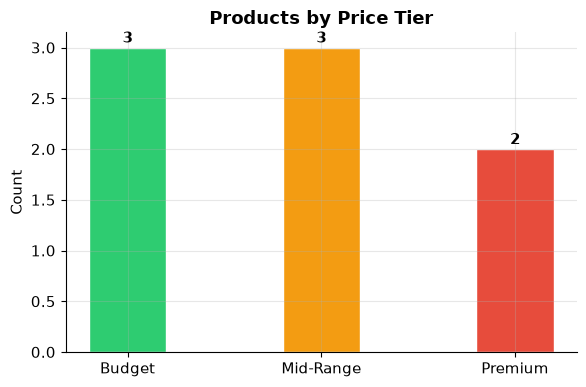

In [ ]:
q24 = pd.read_sql("""
SELECT  product_name,
        category,
        unit_price,
        CASE
            WHEN unit_price < 1000               THEN 'Budget'
            WHEN unit_price BETWEEN 1000 AND 3000 THEN 'Mid-Range'
            WHEN unit_price > 3000               THEN 'Premium'
        END AS price_tier
FROM    products
ORDER BY unit_price
""", con)

display(q24)

tier_colors = {'Budget': '#2ecc71', 'Mid-Range': '#f39c12', 'Premium': '#e74c3c'}
counts = q24['price_tier'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values,
              color=[tier_colors[t] for t in counts.index],
              width=0.4, edgecolor='white')
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.05,
            str(int(b.get_height())), ha='center', fontweight='bold')
ax.set_title('Products by Price Tier', fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

### Q25 · CASE inside aggregate: Delivered vs Not Delivered

In [ ]:
pd.read_sql("""
SELECT
    SUM(CASE WHEN status = 'Delivered' THEN 1 ELSE 0 END)  AS delivered,
    SUM(CASE WHEN status != 'Delivered' THEN 1 ELSE 0 END) AS not_delivered,
    COUNT(*) AS total,
    ROUND(SUM(CASE WHEN status = 'Delivered' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS delivery_rate_pct
FROM orders
""", con)

,delivered,not_delivered,total,delivery_rate_pct
0,6,5,11,54.50


### Q26 · ACID Properties

| | Property | What it means | Example |
|---|---|---|---|
| **A** | Atomicity | All or nothing | Bank transfer: debit + credit both succeed or neither happens |
| **C** | Consistency | Valid state to valid state | Total balance in the bank never changes mid-transfer |
| **I** | Isolation | Concurrent transactions don't interfere | Two users booking the last seat — only one wins |
| **D** | Durability | Committed = permanent | Confirmed order survives even if server crashes immediately after |


### Q27 · Full ACID Transaction

In [ ]:
tx = sqlite3.connect('shopease.db')
tx.execute("PRAGMA foreign_keys = ON")

print("Stock BEFORE:")
display(pd.read_sql("SELECT product_id, product_name, stock_qty FROM products WHERE product_id IN (201, 208)", tx))

try:
    tx.execute("BEGIN")

    tx.execute("DELETE FROM order_items WHERE order_id = 1011")
    tx.execute("DELETE FROM orders WHERE order_id = 1011")

    tx.execute("INSERT INTO orders VALUES (1011, 102, date('now'), 'Pending', 2697.00)")
    tx.execute("INSERT INTO order_items VALUES (5016, 1011, 201, 1, 1499.00, 0)")
    tx.execute("INSERT INTO order_items VALUES (5017, 1011, 208, 2,  599.00, 0)")
    tx.execute("UPDATE products SET stock_qty = stock_qty - 1 WHERE product_id = 201")
    tx.execute("UPDATE products SET stock_qty = stock_qty - 2 WHERE product_id = 208")

    tx.commit()
    print("\nCOMMIT — transaction successful.")

except Exception as e:
    tx.rollback()
    print(f"ROLLBACK — {e}")

print("\nStock AFTER:")
display(pd.read_sql("SELECT product_id, product_name, stock_qty FROM products WHERE product_id IN (201, 208)", tx))

print("\nNew order details:")
display(pd.read_sql("""
    SELECT o.order_id, o.status, o.total_amount, p.product_name, oi.quantity
    FROM   orders o
    JOIN   order_items oi ON oi.order_id  = o.order_id
    JOIN   products    p  ON p.product_id = oi.product_id
    WHERE  o.order_id = 1011
""", tx))
tx.close()

Stock BEFORE:


,product_id,product_name,stock_qty
0,201,Wireless Earbuds,250
1,208,Cushion Covers (Set),400


ROLLBACK — database is locked

Stock AFTER:


,product_id,product_name,stock_qty
0,201,Wireless Earbuds,250
1,208,Cushion Covers (Set),400



New order details:


,order_id,status,total_amount,product_name,quantity


---
## Superstore Dataset Analysis

### Sales by Region

,region,orders,total_sales,total_profit,avg_discount_pct
0,West,1611,725457.82,108418.45,10.90
1,East,1401,678781.24,91522.78,14.50
2,Central,1175,501239.89,39706.36,24.00
3,South,822,391721.91,46749.43,14.70


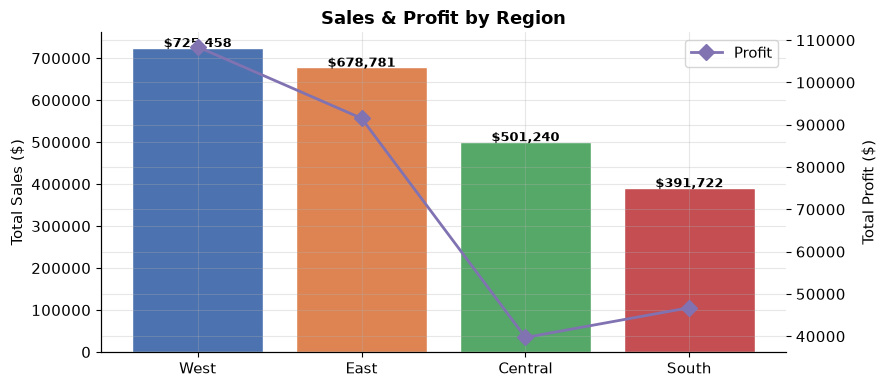

In [ ]:
region = pd.read_sql("""
SELECT   region,
         COUNT(DISTINCT order_id)           AS orders,
         ROUND(SUM(sales), 2)              AS total_sales,
         ROUND(SUM(profit), 2)             AS total_profit,
         ROUND(AVG(discount) * 100, 1)     AS avg_discount_pct
FROM     sales
GROUP BY region
ORDER BY total_sales DESC
""", con)

display(region)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(region['region'], region['total_sales'],
              color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'], edgecolor='white')
ax2 = ax.twinx()
ax2.plot(region['region'], region['total_profit'], 'D-',
         color='#8172B2', linewidth=2, markersize=8, label='Profit')
for b, v in zip(bars, region['total_sales']):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1200,
            f'${v:,.0f}', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Sales & Profit by Region', fontweight='bold')
ax.set_ylabel('Total Sales ($)')
ax2.set_ylabel('Total Profit ($)')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

### Sales by Category

In [ ]:
cat = pd.read_sql("""
SELECT   category,
         COUNT(*)                AS transactions,
         ROUND(SUM(sales), 2)   AS total_sales,
         ROUND(SUM(profit), 2)  AS total_profit,
         ROUND(SUM(profit) * 100.0 / SUM(sales), 1) AS margin_pct
FROM     sales
GROUP BY category
ORDER BY total_sales DESC
""", con)
cat

,category,transactions,total_sales,total_profit,margin_pct
0,Technology,1847,836154.03,145454.95,17.40
1,Furniture,2121,741999.80,18451.27,2.50
2,Office Supplies,6026,719047.03,122490.80,17.00


### Monthly Revenue Trend

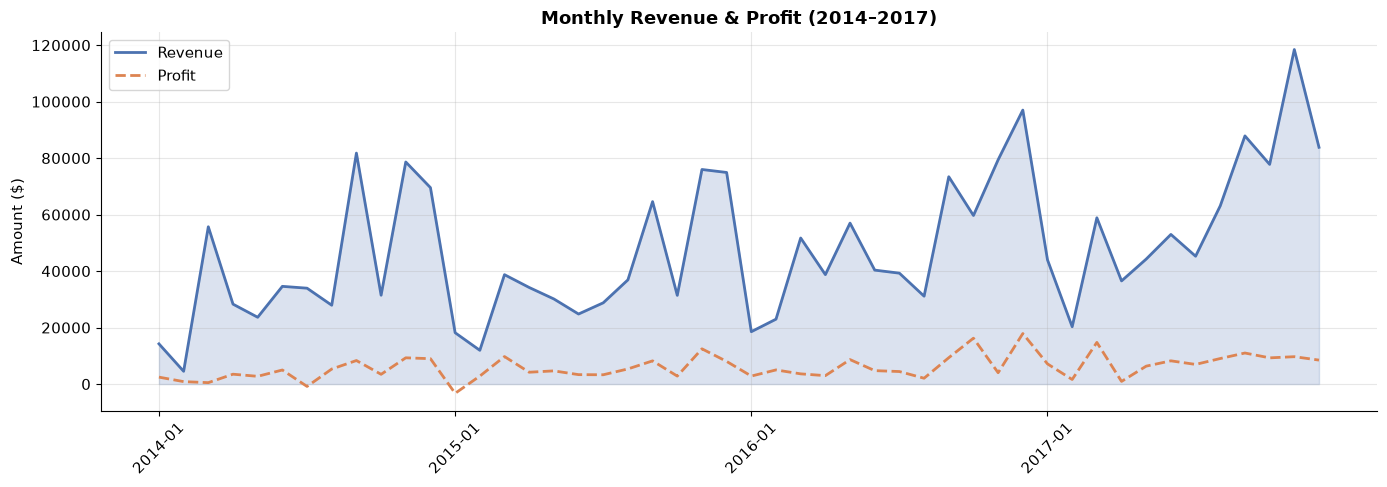

In [ ]:
monthly = pd.read_sql("""
SELECT   year_month,
         ROUND(SUM(sales), 2)  AS revenue,
         ROUND(SUM(profit), 2) AS profit
FROM     sales
GROUP BY year_month
ORDER BY year_month
""", con)

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(monthly))
ax.fill_between(x, monthly['revenue'], alpha=0.2, color='#4C72B0')
ax.plot(x, monthly['revenue'], color='#4C72B0', linewidth=2, label='Revenue')
ax.plot(x, monthly['profit'],  color='#DD8452', linewidth=2, linestyle='--', label='Profit')

ticks = [i for i, ym in enumerate(monthly['year_month']) if ym.endswith('-01')]
ax.set_xticks(ticks)
ax.set_xticklabels([monthly['year_month'].iloc[i] for i in ticks], rotation=45)
ax.set_title('Monthly Revenue & Profit (2014–2017)', fontweight='bold')
ax.set_ylabel('Amount ($)')
ax.legend()
plt.tight_layout()
plt.show()

### Top 10 Customers by Revenue

,customer_name,segment,orders,total_spent
0,Sean Miller,Home Office,5,25043.05
1,Tamara Chand,Corporate,5,19052.22
2,Raymond Buch,Consumer,6,15117.34
3,Tom Ashbrook,Home Office,4,14595.62
4,Adrian Barton,Consumer,10,14473.57
5,Ken Lonsdale,Consumer,12,14175.23
6,Sanjit Chand,Consumer,9,14142.33
7,Hunter Lopez,Consumer,6,12873.30
8,Sanjit Engle,Consumer,11,12209.44
9,Christopher Conant,Consumer,5,12129.07


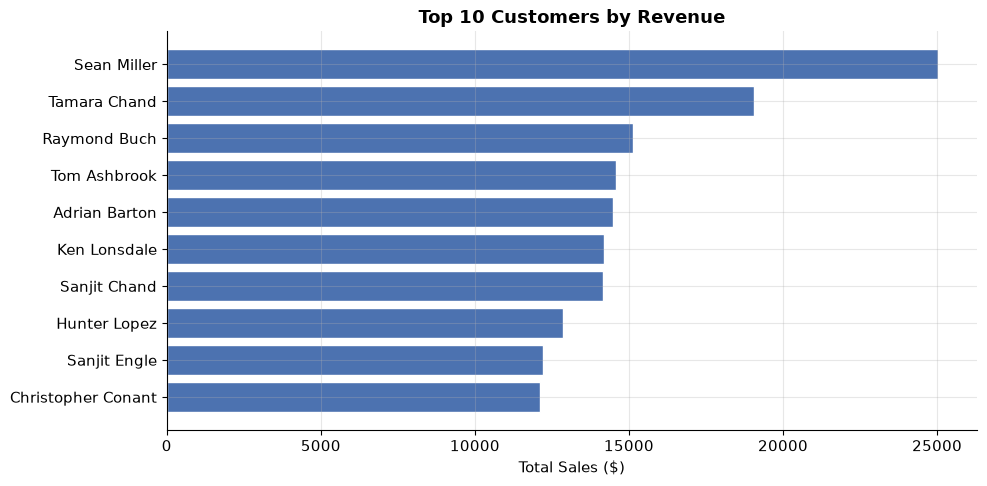

In [ ]:
top_customers = pd.read_sql("""
SELECT   customer_name,
         segment,
         COUNT(DISTINCT order_id) AS orders,
         ROUND(SUM(sales), 2)     AS total_spent
FROM     sales
GROUP BY customer_name, segment
ORDER BY total_spent DESC
LIMIT 10
""", con)

display(top_customers)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_customers['customer_name'][::-1], top_customers['total_spent'][::-1],
        color='#4C72B0', edgecolor='white')
ax.set_title('Top 10 Customers by Revenue', fontweight='bold')
ax.set_xlabel('Total Sales ($)')
plt.tight_layout()
plt.show()

### Top 10 Products by Sales

In [ ]:
pd.read_sql("""
SELECT   product_name,
         category,
         COUNT(*)               AS times_ordered,
         ROUND(SUM(sales), 2)  AS total_sales,
         ROUND(SUM(profit), 2) AS total_profit
FROM     sales
GROUP BY product_name, category
ORDER BY total_sales DESC
LIMIT 10
""", con)

,product_name,category,times_ordered,total_sales,total_profit
0,Canon imageCLASS 2200 Advanced Copier,Technology,5,61599.82,25199.93
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,10,27453.38,7753.04
2,Cisco TelePresence System EX90 Videoconferenci...,Technology,1,22638.48,-1811.08
3,HON 5400 Series Task Chairs for Big and Tall,Furniture,8,21870.58,0.00
4,GBC DocuBind TL300 Electric Binding System,Office Supplies,11,19823.48,2233.51
5,GBC Ibimaster 500 Manual ProClick Binding System,Office Supplies,9,19024.50,760.98
6,Hewlett Packard LaserJet 3310 Copier,Technology,8,18839.69,6983.88
7,HP Designjet T520 Inkjet Large Format Printer ...,Technology,3,18374.90,4094.98
8,GBC DocuBind P400 Electric Binding System,Office Supplies,6,17965.07,-1878.17
9,High Speed Automatic Electric Letter Opener,Office Supplies,3,17030.31,-262.00


### Duplicate Detection

In [ ]:
dupes = pd.read_sql("""
SELECT   order_id, product_id, COUNT(*) AS count
FROM     sales
GROUP BY order_id, product_id
HAVING   COUNT(*) > 1
""", con)

if len(dupes) == 0:
    print("No duplicates found — data is clean.")
else:
    display(dupes)

,order_id,product_id,count
0,CA-2015-103135,OFF-BI-10000069,2
1,CA-2016-129714,OFF-PA-10001970,2
2,CA-2016-137043,FUR-FU-10003664,2
3,CA-2016-140571,OFF-PA-10001954,2
4,CA-2017-118017,TEC-AC-10002006,2
5,CA-2017-152912,OFF-ST-10003208,2
6,US-2014-150119,FUR-CH-10002965,2
7,US-2016-123750,TEC-AC-10004659,2


### Data Quality Check

In [ ]:
pd.read_sql("""
SELECT
    COUNT(*)                                               AS total_rows,
    COUNT(DISTINCT order_id)                               AS unique_orders,
    COUNT(DISTINCT customer_id)                            AS unique_customers,
    COUNT(DISTINCT product_id)                             AS unique_products,
    SUM(CASE WHEN sales < 0 THEN 1 ELSE 0 END)           AS negative_sales,
    SUM(CASE WHEN quantity < 1 THEN 1 ELSE 0 END)         AS invalid_qty,
    ROUND(MIN(sales), 2)                                   AS min_sale,
    ROUND(MAX(sales), 2)                                   AS max_sale,
    ROUND(AVG(sales), 2)                                   AS avg_sale
FROM sales
""", con).T.rename(columns={0: 'Value'})

,Value
total_rows,9994.00
unique_orders,5009.00
unique_customers,793.00
unique_products,1862.00
negative_sales,0.00
invalid_qty,0.00
min_sale,0.44
max_sale,22638.48
avg_sale,229.86
